<table style="border-collapse: collapse; border: none;">
  <tr>
    <td style="vertical-align: top; border: none;">
      <img src="https://i.imgur.com/x6poGzn.png" width="130" height="170" alt="Colaboratory logo" style="margin-right: 10px;">
    </td>
    <td style="border: none;">
      <h1 style="margin-bottom: 0;"><b>Laboratorio 8: Monte Carlo Markov Chain.</b></h1>
      <hr style="margin-top: 5px; margin-bottom: 5px;">
      <div style="font-size: 20px; text-align: left;">
        Física computacional 1.<br>
      </div>
      <div style="font-size: 20px; text-align: left;">
        Nevis Saray Pérez Herrera<br>
      </div>
      <div style="font-size: 13px; text-align: left;">
      <br>Universidad de Antioquia, Instituto de Física<br>
      Mayo de 2026.
      </div>
    </td>
  </tr>
</table>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

1. Realizar la simulación mediante el uso del método de Metrópolis Monte Carlo para este sistema. En este caso, visitar todos los posibles spines de la red cristalina del material e intentar iversiones bajo condiciones adecuadas de energía y estabilidad del sistema. 

In [3]:
l = 15 #tamaño de la red cristalina (lxl)
T = 5 #Temperatura reducida
h = 0.5 #campo magnético reducido
J=0 #ya que el sistema es no interactuante

n_pasos= 100000 #número de pasos

red = np.random.choice([-1,1], size=(l,l))

def magnetizacion(red):
    return np.mean(red)

magnetizaciones =[]

for paso in range(n_pasos):
    i = np.random.randint(0,l)
    j= np.random.randint(0,l)
    s = red[i,j]
    vecinos = (red[(i+1) % l,j] + red[(i-1)%l,j] + red[i, (j+1)%l] + red[i, (j-1) % l])

    delta_E = 2 *s*(J*vecinos + h)
    if delta_E <= 0:
        red[i,j]=-s
    else:
        r = np.random.rand()
        if r < np.exp(-delta_E / T):
            red[i,j]=-s

    if paso % 100 == 0:
        magnetizaciones.append(magnetizacion(red))


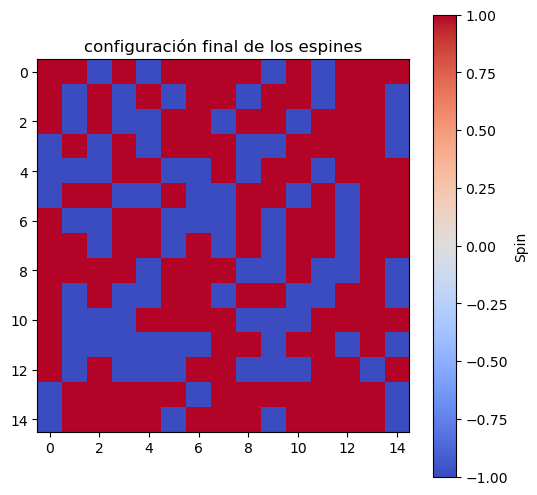

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(red, cmap="coolwarm")
plt.title("configuración final de los espines")
plt.colorbar(label="Spin")
plt.show()


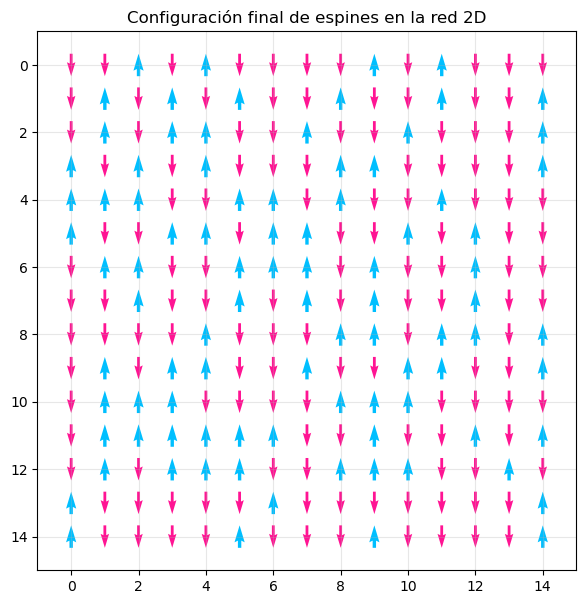

In [5]:
filas, columnas = red.shape
y, x = np.indices((filas, columnas))

up = red == 1
down = red == -1
plt.figure(figsize=(7,7))

plt.quiver(
    x[up], y[up], 
    np.zeros(np.sum(up)), np.ones(np.sum(up)),
    color="deeppink",
    angles="xy", scale_units = "xy", scale=1.5,
    pivot="middle"
)

plt.quiver(x[down], y[down], np.zeros(np.sum(down)), -np.ones(np.sum(down)),
           color="deepskyblue", angles="xy", scale_units = "xy", scale=1.5, pivot="middle" 
)

plt.title("Configuración final de espines en la red 2D")
plt.xlim(-1,columnas)
plt.ylim(-1,filas)
plt.gca().set_aspect("equal")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

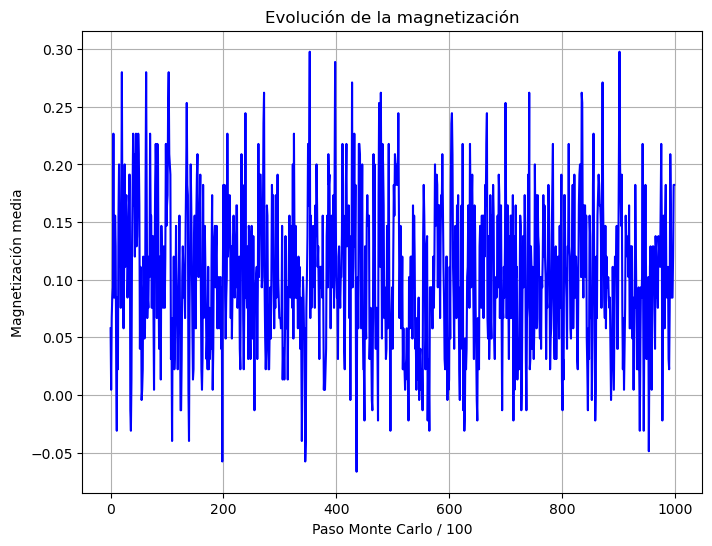

In [6]:
plt.figure(figsize=(8,6))
plt.plot(magnetizaciones, color="b")
plt.xlabel("Paso Monte Carlo / 100")
plt.ylabel("Magnetización media")
plt.title("Evolución de la magnetización")
plt.grid()
plt.show()

Para esta simulación use el método Metrópolis Monte Carlo sobre una red bidimensional $15\times 15$ de espines. Cada sitio de la red representa un átomo con espín $s_i = \pm 1$ que sería espín arriba o  espín abajo.
Inicialmente la configuración se genera de forma aleatoria y en cada paso se escogió un punto de la red para intentar invertir el espín en ese punto. 
Ya que el sistema es no interactuante entonces la energía solo depende del campo magnético externo. La inversión de un espín se acepta automaticamente si disminuía la energía del sistema  pero si esta aumentaba la nueva configuración se acepta con una probabilidad la cual es dada por el factor de Boltzmann y la configuración final se puede ver a través del mapa de calor o mediante las flechas. 

2. Graficar la Magnetización media del material  vs el campo magnético para tres temperaturas reducidas (H/T) con $T = \{5, 15, 20\}K$ y un campo variable $-30G < H < +30G$. Mostrar que la distribución canónica de la magnetización clásica es muy acertada 

In [9]:
#l esta deinido antes
temperaturas = [5, 15, 20]
campos = np.linspace(-30, 30, 31)
#J = 0 definido arriba ya que el sistema es no interactuante
n_equilibrio = 100
n_medicion= 300

def metropolis_ising(l, T, H, n_equilibrio, n_medicion):
    red = np.random.choice([-1, 1], size=(l,l))
    N = l*l

    for sweep in range(n_equilibrio):
        for intento in range(N):
            i = np.random.randint(0,l)
            j = np.random.randint(0,l)

            s = red[i,j]

            delta_E = 2*s*H
            if delta_E <= 0:
                red[i,j]=-s 
            else:
                r = np.random.rand()
                if r< np.exp(-delta_E / T):
                    red[i,j] = -s

    magnetizaciones2 = []

    for sweep in range(n_medicion):
        for intento in range(N):

            i = np.random.randint(0,l)
            j = np.random.randint(0,l)
            s = red[i,j]

            delta_E = 2*s*H

            if delta_E <=0:
                red[i,j] = -s
            else:
                r = np.random.rand()
                if r< np.exp(-delta_E / T):
                    red[i,j] = -s

        magnetizaciones2.append(magnetizacion(red))
    M_promedio = np.mean(magnetizaciones2)
    M_error = np.std(magnetizaciones2)

    return M_promedio, M_error

#aqui guardo los resultados

resultados_MC = {}
errores_MC = {}

for T in temperaturas:
    magnetizaciones_T =[]
    errores_T=[]

    for H in campos: 
        M_mean, M_mistake = metropolis_ising(l, T, H, n_equilibrio, n_medicion)

        magnetizaciones_T.append(M_mean)
        errores_T.append(M_mistake)
    
    resultados_MC[T] = magnetizaciones_T
    errores_MC[T] = errores_T



In [10]:
def magnetizacion_analitica(H, T):
    return np.tanh(H / T)

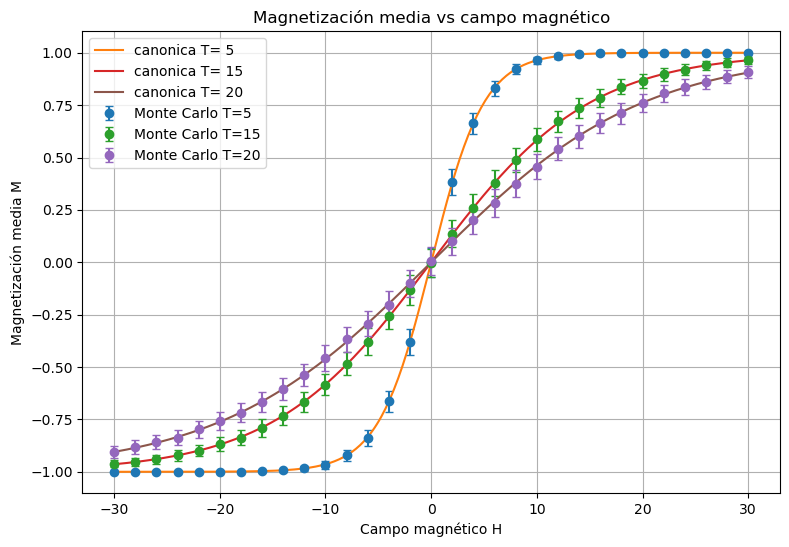

In [13]:
plt.figure(figsize=(9,6))
for T in temperaturas:
    plt.errorbar(campos, resultados_MC[T], yerr = errores_MC[T], fmt = "o", capsize = 3, label = f"Monte Carlo T={T}")

    H_continuo = np.linspace(-30,30,300)
    plt.plot(H_continuo, magnetizacion_analitica(H_continuo, T), label =f"canonica T= {T}")

plt.xlabel("Campo magnético H")
plt.ylabel("Magnetización media M")
plt.title("Magnetización media vs campo magnético")
plt.grid(True)
plt.legend()
plt.show()

Aqui se estudio la magnetización media de un material paramagnetico en función del campo magnético externo para 3 temperaturas reducidas: $T= 5, T=15, T=20$ para cada valor del campo magnético $H$, se realizo una simulación Monte Carlo y se calculó la magnetización media como $M=\frac{1}{N}\sum_i s_i$, Los resultados muestran que para campos magnéticos negativos, la magnetización tiende a valores negativos mientras que para campos positivos tiende a valores positivos. Esto nos dice que los espines se alinean preferentemente con la dirección del campo aplicado.

3. Investigar el resultado analítico para este sistema 2D y comparar con la simulación de MC. ¿Qué tan precisa es la simulación? Explique.

In [14]:
errores_comparacion = {}

for T in temperaturas:
    M_mc = np.array(resultados_MC[T])
    M_teorica = magnetizacion_analitica(campos, T)

    error_absoluto = np.abs(M_mc - M_teorica)
    error_medio = np.mean(error_absoluto)
    error_maximo = np.max(error_absoluto)

    errores_comparacion[T] = {
        "Error medio":error_medio,
        "Error máximo" : error_maximo
    }

    print(f"T = {T}")
    print(f"Error medio absoluto = {error_medio:.4f}")
    print(f"Error máximo absoluto = {error_maximo:.4f}")
    print()
    

T = 5
Error medio absoluto = 0.0008
Error máximo absoluto = 0.0048

T = 15
Error medio absoluto = 0.0025
Error máximo absoluto = 0.0079

T = 20
Error medio absoluto = 0.0035
Error máximo absoluto = 0.0116



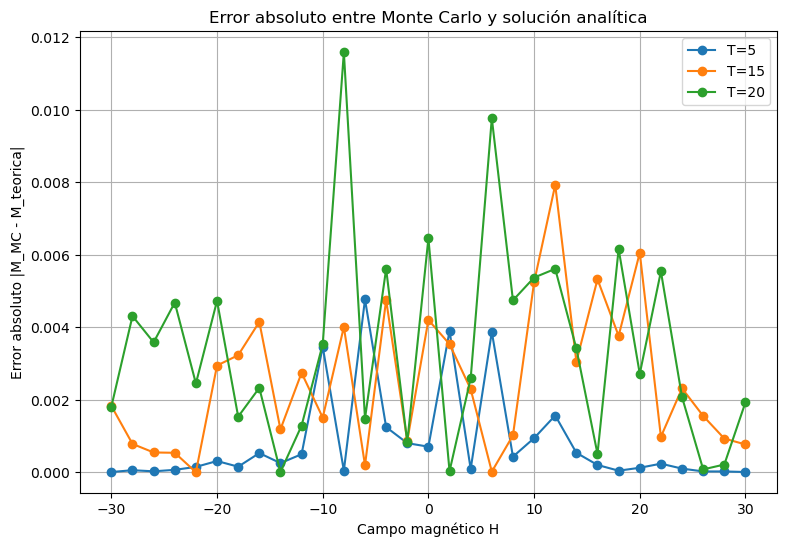

In [15]:
plt.figure(figsize=(9,6))

for T in temperaturas:
    M_mc = np.array(resultados_MC[T])
    M_teorica = magnetizacion_analitica(campos, T)

    error = np.abs(M_mc - M_teorica)
    plt.plot(campos, error, "o-", label=f"T={T}")

plt.xlabel("Campo magnético H")
plt.ylabel("Error absoluto |M_MC - M_teorica|")
plt.title("Error absoluto entre Monte Carlo y solución analítica")
plt.grid(True)
plt.legend()
plt.show()

Para el sistema no interactuante, el resultado analitico se obtiene a partir de la distribución canónica, como no existe interacción entre vecinos, la energía del sistema está dada por:

$E = - H \sum_i s_i$ A partir de la función de un espín se obtiene que la magnetización media teórica está dada por: $M(H,T)= \tanh \left(\frac{H}{T}\right)$

Al comparar la simulación Monte Carlo con este resultado analítico, se observa que ambas curvas presentan el mismo comportamiento general. La magnetización tiende a $-1$ para campos negativos intensos y a $+1$ para campos positivos intensos y se aproxima a cero cuando $H=0$, las pequeñas diferencias entre la simulación y la teoría se deben al tamaño finito de la red, al número limitado de pasos Monte Carlo y a las fluctuaciones aleatorias propias del método, por tanto la simulación es una buena aproximación al resultado analítico cuando se usan sificientes pasos de equilibrio y medición. 